# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

**1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?**

Adding a penalty to MSE discourages the model from using very large coefficients. This helps prevent the model from fitting noise in the data and keeps it simpler, which usually improves how well it performs on new data.

**2. How does regularization provide a way of exploring the bias-variance trade-off?**

Regularization lets us control the bias-variance tradeoff by adjusting how strong the penalty is. A small penalty keeps the model flexible (low bias, high variance), while a large penalty simplifies the model (higher bias, lower variance). Choosing the right amount balances the two.

**3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?**

The main difference is in how they penalize coefficients. Ridge uses squared values (L2), so it shrinks coefficients but keeps all variables in the model. LASSO uses absolute values (L1), which can shrink some coefficients all the way to zero, effectively selecting a smaller set of features.

**4. How do we typically scale variables for use in regularized regression? Why?**

We typically standardize variables (mean 0, standard deviation 1). This is important because regularization depends on the size of coefficients, and without scaling, variables with larger scales would be penalized more unfairly.

**5. How is the penalty $\alpha$ typically selected?**

The penalty α is usually selected using cross-validation. We test different values of α and choose the one that minimizes the prediction error on validation data.

**6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?**

The penalty α is usually selected using cross-validation. We test different values of α and choose the one that minimizes the prediction error on validation data.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

**2.1**

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv("data/cars_hw.csv")

df = df.drop(columns=['Unnamed: 0'])

df['Age'] = 2026 - df['Make_Year']

X_base = df[['Mileage_Run', 'Age']]
y = df['Price']

**2.2**

In [19]:
from sklearn.linear_model import LinearRegression

# Polynomial + scaling (you still need this)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_base)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Linear regression
lr = LinearRegression()
lr.fit(X_scaled, y)

coeffs_lr = pd.Series(lr.coef_, index=feature_names)

# Interaction term
interaction = coeffs_lr['Mileage_Run Age']
print("Interaction coefficient:", interaction)

Interaction coefficient: -1671212.3563918832


The interaction between Mileage_Run and Age is negative. This means that as both mileage and age increase together, the price decreases more strongly than either variable alone would suggest. In other words, older cars with higher mileage lose value at an even faster rate due to their combined effect.

**2.3**

In [20]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=50000)
lasso.fit(X_scaled, y)

coeffs_lasso = pd.Series(lasso.coef_, index=feature_names)

print("Optimal alpha:", lasso.alpha_)

Optimal alpha: 88.58667904100822


LASSO with 20-fold cross-validation was used to select the optimal penalty parameter. The chosen value of α is approximately 88.59, which balances model complexity and predictive performance by shrinking less important coefficients while keeping the most important ones.

**3.4**

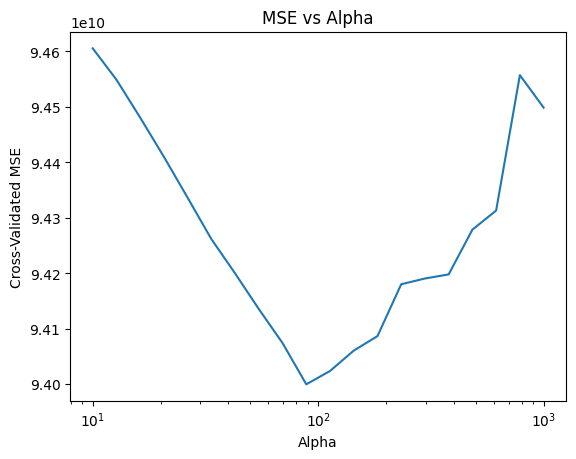

In [21]:
import matplotlib.pyplot as plt

mse_path = lasso.mse_path_.mean(axis=1)

plt.figure()
plt.plot(lasso.alphas_, mse_path)
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("MSE vs Alpha")
plt.show()

The plot shows how cross-validated MSE changes with α and follows a U-shaped pattern. For small α values, the model is more flexible and likely overfitting, while for large α values, the model becomes too simple and underfits. The lowest MSE occurs around α ≈ 88, which matches the optimal value chosen by LASSO and represents the best balance between bias and variance.

**2.5**

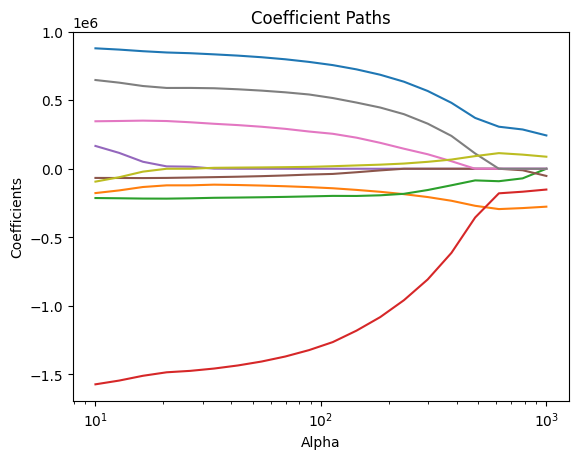

In [22]:
coefs = []

for a in lasso.alphas_:
    l = LassoCV(alphas=[a], cv=20, max_iter=50000)
    l.fit(X_scaled, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(lasso.alphas_, coefs[:, i])

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("Coefficient Paths")
plt.show()

The coefficient paths show how the coefficients change as α increases. As α gets larger, most coefficients shrink toward zero, and some become exactly zero. This shows how LASSO simplifies the model by removing less important features and keeping only the most relevant ones.

**2.6**

In [23]:
coeffs_lasso = pd.Series(lasso.coef_, index=feature_names)

selected = coeffs_lasso[coeffs_lasso != 0]

print("Selected features:")
print(selected)

print("Proportion zero:", (coeffs_lasso == 0).mean())

Selected features:
Mileage_Run          7.790762e+05
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
Mileage_Run^3       -4.240952e+04
Mileage_Run^2 Age    2.715062e+05
Mileage_Run Age^2    5.415432e+05
Age^3                1.374220e+04
dtype: float64
Proportion zero: 0.1111111111111111


LASSO selects most of the polynomial features, including Mileage_Run, Age, and several interaction and higher-order terms. About 11% of the coefficients are set to zero, meaning only a small number of features are removed. This suggests that most of the polynomial terms contribute to predicting price, although LASSO still simplifies the model slightly by eliminating less important features.

**2.7**

In [24]:
comparison = pd.DataFrame({
    'Linear': coeffs_lr,
    'LASSO': coeffs_lasso
})

print(comparison)

                         Linear         LASSO
Mileage_Run        9.117748e+05  7.790762e+05
Age               -2.481722e+05 -1.339534e+05
Mileage_Run^2     -2.072926e+05 -2.015634e+05
Mileage_Run Age   -1.671212e+06 -1.322419e+06
Age^2              3.505507e+05  0.000000e+00
Mileage_Run^3     -6.514490e+04 -4.240952e+04
Mileage_Run^2 Age  3.388195e+05  2.715062e+05
Mileage_Run Age^2  7.167816e+05  5.415432e+05
Age^3             -2.100379e+05  1.374220e+04


Compared to linear regression, most coefficients decrease in magnitude under LASSO due to regularization. For example, the coefficients for Mileage_Run and the interaction term both shrink noticeably. LASSO also sets some coefficients exactly to zero, such as Age², showing feature selection. Most coefficients keep the same sign, but Age³ changes from negative to positive, which likely happens because LASSO adjusts for correlations between variables while shrinking them. Overall, LASSO produces a simpler model with smaller coefficients while keeping the most important relationships.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

**3.1**

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Load data
df = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")

# Continuous variables
X_cont = df[['age', 'ejection_fraction', 'serum_creatinine']]

# Polynomial (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_cont)
poly_names = poly.get_feature_names_out(['age','ejection_fraction','serum_creatinine'])

# Scale
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

In [28]:
# Dummy variables (already 0/1)
X_cat = df[['anaemia','diabetes','high_blood_pressure','smoking']]

poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_int = poly_cat.fit_transform(X_cat)
cat_names = poly_cat.get_feature_names_out(X_cat.columns)

In [29]:
X = np.hstack([X_poly_scaled, X_cat_int])
feature_names = list(poly_names) + list(cat_names)

y = df['DEATH_EVENT']

**3.2**

In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)

coeffs_lr = pd.Series(lr.coef_, index=feature_names)
print(coeffs_lr)

age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.072156
anaemia                        

Some coefficients appear counterintuitive. For example, age has a positive coefficient, while age² is negative, which seems contradictory at first. Similarly, some interaction terms have signs that don’t immediately match expected medical relationships.This happens because the model includes higher-order and interaction terms, which allow for nonlinear relationships. Instead of each variable having a simple linear effect, their impact depends on combinations of values. For example, age might increase risk up to a point, but the negative age² term suggests the effect slows or reverses at higher values. These additional terms help capture more complex patterns and explain why individual coefficients may seem inconsistent on their own.

**3.3**

In [31]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=50000)
lasso.fit(X, y)

coeffs_lasso = pd.Series(lasso.coef_, index=feature_names)

print("Optimal alpha:", lasso.alpha_)

Optimal alpha: 0.005736152510448681


LASSO with 20-fold cross-validation selects an optimal α of approximately 0.0057. This relatively small value suggests that only a small amount of regularization is needed, allowing the model to keep more features while still reducing overfitting.

**3.4**

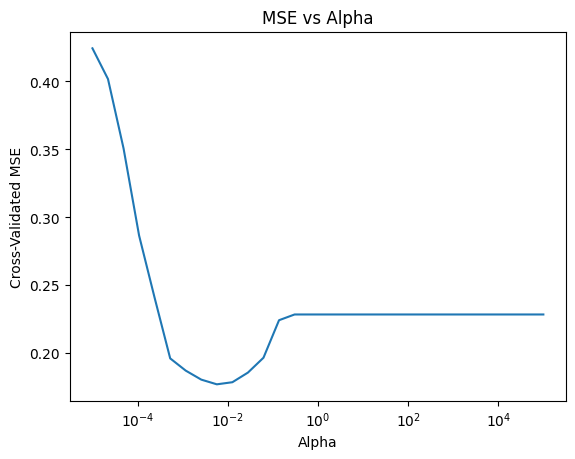

In [32]:
import matplotlib.pyplot as plt

mse_path = lasso.mse_path_.mean(axis=1)

plt.figure()
plt.plot(lasso.alphas_, mse_path)
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("MSE vs Alpha")
plt.show()

The MSE plot shows a clear U-shaped pattern. For very small α values, the model overfits and has higher error. As α increases, the error decreases and reaches its lowest point around α ≈ 0.0057. After that, the error increases again as the model becomes too simple and underfits. This shows the bias-variance tradeoff, where the optimal α balances model complexity and prediction accuracy.

**3.5**

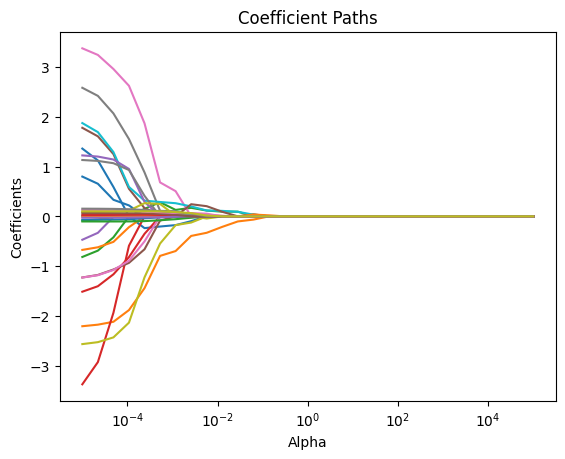

In [33]:
coefs = []

for a in lasso.alphas_:
    l = LassoCV(alphas=[a], cv=20, max_iter=50000)
    l.fit(X, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(lasso.alphas_, coefs[:, i])

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("Coefficient Paths")
plt.show()

The coefficient paths show that as α increases, most coefficients shrink toward zero, and many eventually become exactly zero. This demonstrates how LASSO performs feature selection by removing less important variables. Larger coefficients shrink more gradually, while smaller ones are driven to zero more quickly as regularization increases.

**3.6**

In [34]:
selected = coeffs_lasso[coeffs_lasso != 0]

print("Selected features:")
print(selected)

print("Proportion zero:", (coeffs_lasso == 0).mean())

Selected features:
ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64
Proportion zero: 0.5862068965517241


In [35]:
comparison = pd.DataFrame({
    'Linear': coeffs_lr,
    'LASSO': coeffs_lasso
})

print(comparison)

                                          Linear     LASSO
age                                     1.539156 -0.000000
ejection_fraction                      -2.192494 -0.329656
serum_creatinine                       -0.853588  0.116875
age^2                                  -3.678654  0.000000
age ejection_fraction                  -0.600918 -0.000000
age serum_creatinine                    1.841563  0.000000
ejection_fraction^2                     3.430976  0.000000
ejection_fraction serum_creatinine      2.673394  0.000000
serum_creatinine^2                     -2.647041 -0.000000
age^3                                   1.993135  0.117992
age^2 ejection_fraction                 0.908026  0.000000
age^2 serum_creatinine                 -0.697522  0.000000
age ejection_fraction^2                -0.081206  0.000000
age ejection_fraction serum_creatinine -1.577665  0.000000
age serum_creatinine^2                  1.284099 -0.000000
ejection_fraction^3                    -1.250341  0.2048

LASSO selects a smaller subset of features, including ejection_fraction, serum_creatinine, and several higher-order and interaction terms. About 58.6% of the coefficients are set to zero, showing that LASSO removes many less important features and significantly simplifies the model Compared to linear regression, most coefficients shrink in magnitude under LASSO, and many are reduced to exactly zero. Some coefficients also change sign. For example, serum_creatinine changes from negative in the linear model to positive in LASSO, and ejection_fraction³ changes from negative to positive. These changes occur because LASSO adjusts for correlations between variables while shrinking coefficients.Overall, the LASSO model produces more reasonable and stable results. By reducing variance and eliminating unnecessary features, it avoids overfitting, even though it introduces some bias. From a bias-variance perspective, this tradeoff leads to better generalization and makes the LASSO results more interpretable than the original linear regression.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

**4.1**

The ridge regression objective function is given by
$\frac{1}{n} \sum_{i=1}^{n} \left( \tilde{y}_i - \tilde{b}_1 \tilde{x}_i \right)^2 + \alpha \tilde{b}_1^2$.

This adds a penalty term to the mean squared error that discourages large values of the slope coefficient.

**4.2**

Because the data is mean-centered, the intercept is $\tilde{b}_0 = 0$.

The slope is given by
$\tilde{b}1 = \frac{\sum{i=1}^{n} \tilde{x}_i \tilde{y}i}{\sum{i=1}^{n} \tilde{x}_i^2 + n\alpha}$.

This shows that ridge regression shrinks the slope compared to the ordinary least squares solution.

**4.3**

As $\alpha$ increases, the denominator of $\tilde{b}_1$ increases, so the slope shrinks toward zero.

In other words, $\tilde{b}_1 \to 0$ as $\alpha$ becomes large.

This reduces model complexity and helps prevent overfitting.

**4.4**

The LASSO objective function is
$\frac{1}{n} \sum_{i=1}^{n} \left( \tilde{y}_i - \tilde{b}_1 \tilde{x}_i \right)^2 + \alpha |\tilde{b}_1|$.

The challenge is that $|\tilde{b}_1|$ is not differentiable at zero, so standard derivative methods do not apply.

The optimal solution sets $\tilde{b}1 = 0$ when
$\left| \sum{i=1}^{n} \tilde{x}_i \tilde{y}_i \right| \leq \frac{n\alpha}{2}$ when the correlation between x and y is small relative to the penalty.

This shows that LASSO can completely eliminate the variable when the relationship between $x$ and $y$ is not strong enough relative to the penalty.